In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Load dataset (look in current dir or project root)
_csv = Path("synthetic_transactions_sample_cleaned.csv")
if not _csv.exists():
    _csv = Path.cwd() / "synthetic_transactions_sample_cleaned.csv"
dataset = pd.read_csv(_csv)
dataset.head()

,description,category
0,Grocery shopping at Walmart,Food
1,Monthly rent payment,Rent
2,Netflix subscription,Entertainment
3,Electricity bill payment,Utilities
4,Uber to office,Transport


In [2]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /home/mukama/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [3]:
# Cleaning the texts
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

corpus = []
number_of_rows = dataset.shape[0]
# Use first column for text (works whether it's named "Text", "text", or "Transaction text")
text_col = dataset.columns[0]
for i in range(0, number_of_rows): 
    text = re.sub('[^a-zA-Z0-9]', ' ', str(dataset[text_col].iloc[i])) # use regex to remove all non-alphabetical symbols
    text = text.lower()
    text = text.split()
    ps = PorterStemmer()
    text = [ps.stem(word) for word in text if not word in set(stopwords.words('english'))]
    text = [ps.stem(word) for word in text if not word in set(stopwords.words('danish'))]
    text = ' '.join(text)
    corpus.append(text)

# MORE OPTIONS: 
# 1) remove parts of the string which may contain sensitive information (e.g. contract number) or
#    is described in other features (e.g. date, transaction amount)

In [19]:
# Creating the Bag of Words model
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(max_features = 200)
X = cv.fit_transform(corpus).toarray()
y = dataset.iloc[:, 1]

# Splitting the dataset into the Training set and Test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [4]:
# Split first, then fit vectorizer only on training data (avoids data leakage)
try:
    label_col_idx
except NameError:
    label_col_idx = 1
    if 'Category' in dataset.columns:
        label_col_idx = list(dataset.columns).index('Category')
y = dataset.iloc[:, label_col_idx]
from sklearn.model_selection import train_test_split
try:
    corpus_train, corpus_test, y_train, y_test = train_test_split(
        corpus, y, test_size=0.2, random_state=0, stratify=y
    )
    print("Split: stratified (all categories in train & test)")
except ValueError:
    corpus_train, corpus_test, y_train, y_test = train_test_split(
        corpus, y, test_size=0.2, random_state=0
    )
    print("Split: standard (stratify skipped — some categories have too few samples)")

# Bag of Words: fit on train only, transform both
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
X_train = cv.fit_transform(corpus_train).toarray()
X_test = cv.transform(corpus_test).toarray()

Split: stratified (all categories in train & test)


In [6]:
## Logistic regression classification
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression()
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
acc

0.7076923076923077

In [7]:
## Random forest tree classification
# Fitting Random Forest Classification to the Training set
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

# Predicting the Test set results
y_pred = classifier.predict(X_test)

# Making the Confusion Matrix
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
acc

0.6923076923076923

MODEL PERFORMANCE ON TEST SET

--- Naive Bayes ---
Accuracy: 0.6615

Classification report (precision, recall, F1 per category):
               precision    recall  f1-score   support

    Education       0.71      0.83      0.77         6
Entertainment       0.67      0.67      0.67         6
         Food       0.78      0.58      0.67        12
       Health       1.00      0.67      0.80         6
         Rent       0.35      1.00      0.52         6
       Salary       0.60      0.50      0.55         6
     Shopping       0.75      0.60      0.67         5
    Transport       0.88      0.58      0.70        12
    Utilities       0.80      0.67      0.73         6

     accuracy                           0.66        65
    macro avg       0.73      0.68      0.67        65
 weighted avg       0.74      0.66      0.68        65

Confusion matrix (rows=true, cols=predicted):
[[5 0 0 0 0 1 0 0 0]
 [1 4 0 0 1 0 0 0 0]
 [0 0 7 0 4 0 1 0 0]
 [0 0 0 4 2 0 0 0 0]
 [0 0 0 0 6 0 0 0 0]
 [

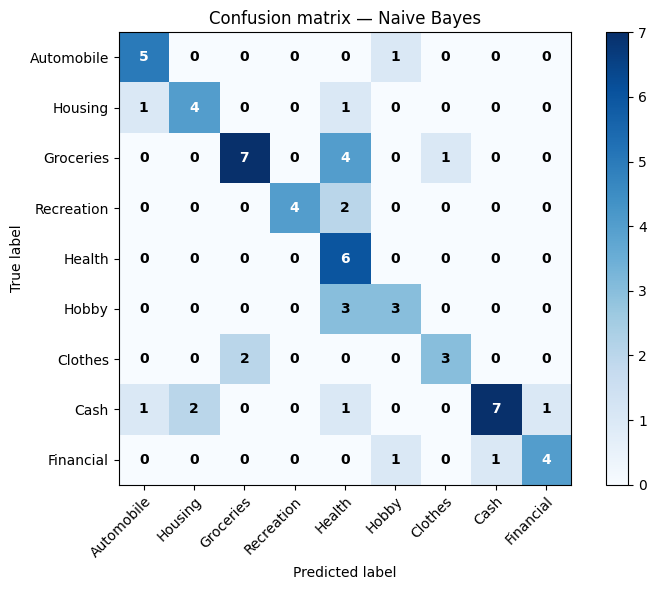


--- Logistic Regression ---
Accuracy: 0.7077

Classification report (precision, recall, F1 per category):
               precision    recall  f1-score   support

    Education       0.71      0.83      0.77         6
Entertainment       0.75      0.50      0.60         6
         Food       0.80      0.67      0.73        12
       Health       1.00      0.50      0.67         6
         Rent       1.00      0.67      0.80         6
       Salary       0.83      0.83      0.83         6
     Shopping       1.00      0.60      0.75         5
    Transport       0.48      1.00      0.65        12
    Utilities       1.00      0.50      0.67         6

     accuracy                           0.71        65
    macro avg       0.84      0.68      0.72        65
 weighted avg       0.80      0.71      0.71        65

Confusion matrix (rows=true, cols=predicted):
[[ 5  0  0  0  0  0  0  1  0]
 [ 1  3  0  0  0  0  0  2  0]
 [ 0  0  8  0  0  0  0  4  0]
 [ 0  1  0  3  0  0  0  2  0]
 [ 0  0  

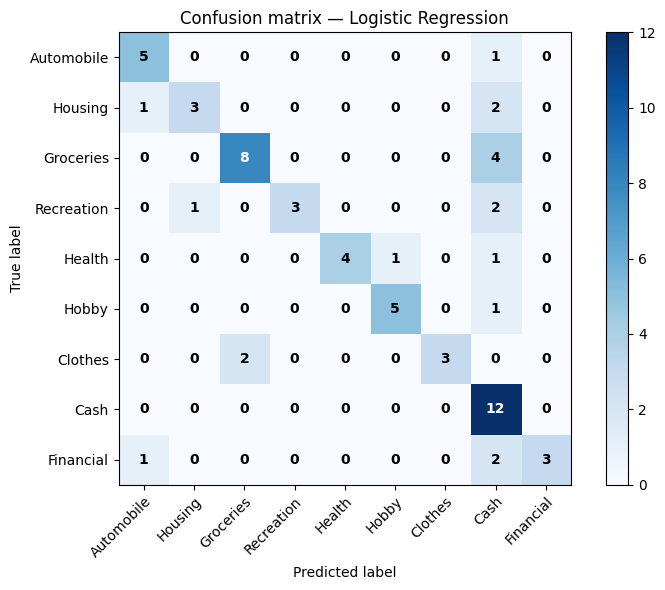


--- Random Forest ---
Accuracy: 0.6923

Classification report (precision, recall, F1 per category):
               precision    recall  f1-score   support

    Education       0.86      1.00      0.92         6
Entertainment       0.40      0.33      0.36         6
         Food       0.46      0.92      0.61        12
       Health       1.00      0.50      0.67         6
         Rent       1.00      0.67      0.80         6
       Salary       0.83      0.83      0.83         6
     Shopping       0.75      0.60      0.67         5
    Transport       0.89      0.67      0.76        12
    Utilities       1.00      0.50      0.67         6

     accuracy                           0.69        65
    macro avg       0.80      0.67      0.70        65
 weighted avg       0.78      0.69      0.70        65

Confusion matrix (rows=true, cols=predicted):
[[ 6  0  0  0  0  0  0  0  0]
 [ 0  2  3  0  0  0  0  1  0]
 [ 0  0 11  0  0  0  1  0  0]
 [ 0  1  2  3  0  0  0  0  0]
 [ 0  0  1  0  

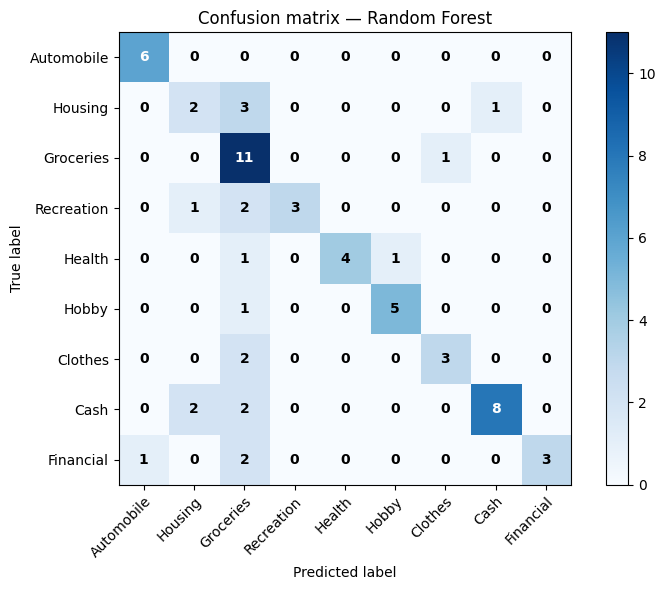

In [8]:
# Performance comparison: test all models on the test set
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

models = {
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=10, criterion="entropy", random_state=0),
}

# Category names for plot labels (optional; uses ids if not all present in data)
category_names = [
    "Automobile", "Housing", "Groceries", "Recreation", "Health",
    "Hobby", "Clothes", "Cash", "Financial", "Other"
]

def plot_confusion_matrix(cm, name, labels=None):
    """Draw confusion matrix as a heatmap."""
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.figure.colorbar(im, ax=ax)
    n = cm.shape[0]
    # Use names only if we have exactly n labels; otherwise use class indices
    if labels is not None and len(labels) >= n:
        tick_labels = labels[:n]
    else:
        tick_labels = [str(i) for i in range(n)]
    ax.set(xticks=np.arange(n), yticks=np.arange(n),
           xticklabels=tick_labels, yticklabels=tick_labels,
           title=f"Confusion matrix — {name}",
           ylabel="True label", xlabel="Predicted label")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    for i in range(n):
        for j in range(n):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontweight="bold")
    fig.tight_layout()
    plt.show()

print("=" * 60)
print("MODEL PERFORMANCE ON TEST SET")
print("=" * 60)

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification report (precision, recall, F1 per category):")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion matrix (rows=true, cols=predicted):")
    print(cm)
    # Draw confusion matrix
    plot_confusion_matrix(cm, name, category_names)

In [24]:
categories = {
    0:'Automobile and Transport',
    1:'Housing and Real-Estate',
    2:'Groceries',
    3:'Recreation and Leisure',
    4:'Health and Well Being',
    5:'Hobby and Knowledge',
    6:'Clothes and Equipment',
    7:'Cash and Credit',
    8:'Financial Services',
    9:'Other'
}

def get_category_by_id(id):
    # Classifier predicts string labels (e.g. 'Transport', 'Food'); categories dict uses int keys.
    if isinstance(id, str):
        return id
    return categories[id]

In [25]:
inputs = ['lidl', 'netto ))', 'netflix', 'kfc', 'rent', 'spotify']
predictions = classifier.predict(cv.transform(inputs))
{ inputs[id]: get_category_by_id(predictions[id]) for id in range(predictions.size) }

{'lidl': 'Food',
 'netto ))': 'Food',
 'netflix': 'Entertainment',
 'kfc': 'Food',
 'rent': 'Rent',
 'spotify': 'Food'}

In [29]:
# Quick date entry: categorize a free-text statement (e.g. "i spent 4k on netflix sub")
# Use the same preprocessing as training so the model sees consistent text.
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

def preprocess_for_model(raw_text):
    """Same cleaning as training: keep only letters/numbers, lower, stem, remove stopwords (en + da)."""
    text = re.sub(r'[^a-zA-Z0-9]', ' ', str(raw_text))
    text = text.lower().split()
    ps = PorterStemmer()
    en_stop = set(stopwords.words('english'))
    da_stop = set(stopwords.words('danish'))
    text = [ps.stem(w) for w in text if w not in en_stop and w not in da_stop]
    return ' '.join(text)

def predict_category(statement, clf=classifier, vectorizer=cv, category_map=categories):
    """Predict category for one statement (e.g. 'i spent 4k on netflix sub' -> Recreation and Leisure)."""
    preprocessed = preprocess_for_model(statement)
    X = vectorizer.transform([preprocessed])
    pred = clf.predict(X)[0]
    # Classifier returns string labels (e.g. 'Food', 'Entertainment'); category_map has int keys.
    if isinstance(pred, str):
        return pred
    return category_map.get(pred, 'Other')

# Demo: your quick-entry example (entertainment = Recreation and Leisure, id 3)
demo = "i spent 4k on gas "
print(f"Statement: \"{demo}\"")
print(f"Predicted category: {predict_category(demo)}")

Statement: "i spent 4k on gas "
Predicted category: Transport
